# Portfolio Construction and Risk Aggregation

This notebook demonstrates how to build a multi-instrument portfolio and aggregate risk using the `neon` library.

## Topics covered

- **Option portfolio** — long/short European options combined into a portfolio; net Greeks computed by `RiskEngine`
- **Bond portfolio** — two fixed-rate bonds held at different quantities; portfolio DV01, modified duration, and convexity
- **Greeks netting** — how delta, gamma, vega, theta, and rho partially offset across positions
- **Bond risk aggregation** — value-weighted duration and convexity across a bond book

## Architecture note

`Bond` does not subclass `Instrument`, so it cannot participate in the option Greeks methods (`net_delta`, `net_gamma`, etc.).  
The solution used here is **two separate portfolios** fed into two separate `RiskEngine` instances:

| Portfolio | Contents | RiskEngine methods used |
|---|---|---|
| `options_portfolio` | `EuropeanOption` positions only | `net_delta/gamma/vega/theta/rho` |
| `bond_portfolio` | `Bond` positions only | `bond_risk(settle, ytms)` |

## Imports

In [1]:
from neon.lib.instruments.options.option_inputs import OptionInputs
from neon.lib.instruments.options.option_type import OptionType
from neon.lib.instruments.options.european import EuropeanOption
from neon.lib.greeks.analytical_greeks import AnalyticalGreeks
from neon.lib.fixed_income.bond import Bond
from neon.lib.portfolio.portfolio import Portfolio
from neon.lib.portfolio.position import Position
from neon.lib.risk.risk_engine import RiskEngine, BondRisk
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

print('All imports OK')

All imports OK


## 1. Option Portfolio

We construct a three-leg option position on the same underlying (spot = 100, vol = 20%, rate = 5%, 1-year expiry):

| Leg | Type | Strike | Quantity | Rationale |
|---|---|---|---|---|
| A | Call | 95 | +10 | Long ITM call — positive delta |
| B | Call | 105 | −5 | Short OTM call — sells upside, reduces delta |
| C | Put | 100 | +5 | Long ATM put — adds negative delta, positive gamma |

Net position: moderately long delta, long gamma and vega.

In [2]:
CURRENT_DATE = '20250101'
EXPIRY_DATE  = '20260101'
SPOT         = 100.0
VOL          = 0.20
RATE         = 0.05
TICKER       = 'SPX'

def make_option(strike: float, option_type: OptionType) -> EuropeanOption:
    inputs = OptionInputs(
        underlying_ticker=TICKER,
        underlying_price=SPOT,
        strike_price=strike,
        volatility=VOL,
        risk_free_rate=RATE,
        current_date=CURRENT_DATE,
        expiry_date=EXPIRY_DATE,
        option_type=option_type,
    )
    return EuropeanOption(inputs, AnalyticalGreeks())

call_95  = make_option(strike=95,  option_type=OptionType.Call)
call_105 = make_option(strike=105, option_type=OptionType.Call)
put_100  = make_option(strike=100, option_type=OptionType.Put)

# Build options portfolio
options_portfolio = Portfolio(name='options_book')
options_portfolio.add_position(Position(instrument=call_95,  quantity=10))
options_portfolio.add_position(Position(instrument=call_105, quantity=-5))
options_portfolio.add_position(Position(instrument=put_100,  quantity=5))

print('Option positions:')
labels = [
    'Long 10x Call K=95',
    'Short 5x Call K=105',
    'Long 5x Put K=100',
]
for label, pos in zip(labels, options_portfolio.positions):
    print(f'  {label:<22}  price={pos.instrument.price():.4f}  position value={pos.value():.2f}')

print(f'\nPortfolio total value: {options_portfolio.value():.2f}')

Option positions:
  Long 10x Call K=95      price=13.3465  position value=133.46
  Short 5x Call K=105     price=8.0214  position value=-40.11
  Long 5x Put K=100       price=5.5735  position value=27.87

Portfolio total value: 121.23


## 2. Option Greeks

`RiskEngine` aggregates Greeks as `sum(quantity_i * greek_i)` across all positions.

Key relationships to watch:
- **Delta** — net directional exposure; positive means the book profits if spot rises
- **Gamma** — rate of change of delta; all long options contribute positive gamma
- **Vega** — exposure to implied vol; long options are long vega
- **Theta** — time decay; long options lose value daily (negative theta)
- **Rho** — sensitivity to the risk-free rate

In [3]:
opt_engine = RiskEngine(options_portfolio)

net_delta = opt_engine.net_delta()
net_gamma = opt_engine.net_gamma()
net_vega  = opt_engine.net_vega()
net_theta = opt_engine.net_theta()
net_rho   = opt_engine.net_rho()

print('Net portfolio Greeks')
print(f'  Delta : {net_delta:+.4f}  ($ P&L per $1 spot move)')
print(f'  Gamma : {net_gamma:+.6f}  (delta change per $1 spot move)')
print(f'  Vega  : {net_vega:+.4f}  ($ P&L per 1-point vol move)')
print(f'  Theta : {net_theta:+.4f}  ($ P&L per year of time decay)')
print(f'  Rho   : {net_rho:+.4f}  ($ P&L per 1-point rate move)')

# Per-position breakdown
print('\nPer-position Greek contributions:')
print(f'{"Position":<22}  {"delta":>8}  {"gamma":>10}  {"vega":>8}  {"theta":>8}')
print('-' * 70)
for label, pos in zip(labels, options_portfolio.positions):
    g = pos.instrument.greeks
    q = pos.quantity
    print(
        f'{label:<22}  '
        f'{q * g.delta():+8.4f}  '
        f'{q * g.gamma():+10.6f}  '
        f'{q * g.vega():+8.4f}  '
        f'{q * g.theta():+8.4f}'
    )
print('-' * 70)
print(
    f'{"NET":<22}  '
    f'{net_delta:+8.4f}  '
    f'{net_gamma:+10.6f}  '
    f'{net_vega:+8.4f}  '
    f'{net_theta:+8.4f}'
)

Net portfolio Greeks
  Delta : +2.7520  ($ P&L per $1 spot move)
  Gamma : +0.160597  (delta change per $1 spot move)
  Vega  : +321.1948  ($ P&L per 1-point vol move)
  Theta : -39.8181  ($ P&L per year of time decay)
  Rho   : +153.9731  ($ P&L per 1-point rate move)

Per-position Greek contributions:
Position                   delta       gamma      vega     theta
----------------------------------------------------------------------
Long 10x Call K=95       +7.2790   +0.165964  +331.9273  -62.9144
Short 5x Call K=105      -2.7111   -0.099176  -198.3526  +31.3856
Long 5x Put K=100        -1.8158   +0.093810  +187.6202   -8.2894
----------------------------------------------------------------------
NET                      +2.7520   +0.160597  +321.1948  -39.8181


## 3. Bond Portfolio

We create two plain vanilla semi-annual coupon bonds:

| Bond | Coupon | Maturity | Quantity | Description |
|---|---|---|---|---|
| A | 4% | 2035-01-01 | 100 | Long-dated, lower coupon |
| B | 6% | 2030-01-01 | 50 | Shorter, higher coupon |

Both are priced at a flat YTM of 5%.

Note: `Bond` objects are passed as `Position.instrument` via Python duck typing — `RiskEngine.bond_risk()` uses `isinstance(p.instrument, Bond)` to identify bond positions, bypassing the `Instrument` ABC hierarchy.

In [4]:
SETTLE = '20250101'

bond_a = Bond(
    issue_date='20250101',
    maturity_date='20350101',
    coupon_rate=0.04,
    coupon_freq=2,
    face=100.0,
)

bond_b = Bond(
    issue_date='20250101',
    maturity_date='20300101',
    coupon_rate=0.06,
    coupon_freq=2,
    face=100.0,
)

YTM_A = 0.05
YTM_B = 0.05

# Bond positions (quantity = number of bonds / face-amount units)
bond_portfolio = Portfolio(name='bond_book')
bond_portfolio.add_position(Position(instrument=bond_a, quantity=100))
bond_portfolio.add_position(Position(instrument=bond_b, quantity=50))

# Price each bond
clean_a = bond_a.clean_price_from_ytm(SETTLE, YTM_A)
clean_b = bond_b.clean_price_from_ytm(SETTLE, YTM_B)
dirty_a = bond_a.dirty_price_from_ytm(SETTLE, YTM_A)
dirty_b = bond_b.dirty_price_from_ytm(SETTLE, YTM_B)

print('Bond pricing at YTM = 5%:')
print(f'  Bond A (4% coupon, 10y):  clean={clean_a:.4f}  dirty={dirty_a:.4f}')
print(f'  Bond B (6% coupon,  5y):  clean={clean_b:.4f}  dirty={dirty_b:.4f}')
print()
print('Note: Bond A trades at a discount (coupon < YTM); Bond B at a premium (coupon > YTM).')

# Total portfolio market value (quantity × dirty price)
mv_a = 100 * dirty_a
mv_b = 50  * dirty_b
print(f'\nMarket value — Bond A (×100): {mv_a:,.2f}')
print(f'Market value — Bond B (×50) : {mv_b:,.2f}')
print(f'Total market value          : {mv_a + mv_b:,.2f}')

Bond pricing at YTM = 5%:
  Bond A (4% coupon, 10y):  clean=92.2054  dirty=92.2054
  Bond B (6% coupon,  5y):  clean=104.3760  dirty=104.3760

Note: Bond A trades at a discount (coupon < YTM); Bond B at a premium (coupon > YTM).

Market value — Bond A (×100): 9,220.54
Market value — Bond B (×50) : 5,218.80
Total market value          : 14,439.34


## 4. Bond Risk

`RiskEngine.bond_risk()` computes portfolio-level:

- **DV01** — total dollar value of 1bp parallel yield shift (sum across positions)
- **Modified duration** — value-weighted average duration across positions
- **Convexity** — value-weighted average convexity
- **Spread DV01** — same as DV01 when no credit spreads are provided (parallel shift of ytm+spread)

The `ytms` dict maps each `Bond` object directly to its YTM.

In [5]:
from neon.lib.fixed_income.bond_analytics import BondAnalytics

bond_engine = RiskEngine(bond_portfolio)

ytms = {bond_a: YTM_A, bond_b: YTM_B}

risk: BondRisk = bond_engine.bond_risk(settle_date=SETTLE, ytms=ytms)

print('Portfolio bond risk (YTM = 5% flat):')
print(f'  DV01              : {risk.dv01:.4f}   ($ per 1bp parallel shift)')
print(f'  Modified duration : {risk.modified_duration:.4f} years')
print(f'  Convexity         : {risk.convexity:.4f}')
print(f'  Spread DV01       : {risk.spread_dv01:.4f}   (= DV01 when no credit spread)')

# Per-bond breakdown for context
ana_a = BondAnalytics(bond_a)
ana_b = BondAnalytics(bond_b)

print('\nPer-bond risk contributions:')
print(f'{"Bond":<20}  {"qty":>5}  {"DV01/bond":>10}  {"pos DV01":>10}  {"mod dur":>9}  {"convexity":>10}')
print('-' * 75)
for label, bond, ytm, qty, ana in [
    ('Bond A (4%, 10y)', bond_a, YTM_A, 100, ana_a),
    ('Bond B (6%,  5y)', bond_b, YTM_B, 50,  ana_b),
]:
    dv01_per = ana.dv01(SETTLE, ytm)
    mod_dur  = ana.modified_duration(SETTLE, ytm)
    conv     = ana.convexity(SETTLE, ytm)
    print(
        f'{label:<20}  {qty:>5}  '
        f'{dv01_per:>10.4f}  '
        f'{qty * dv01_per:>10.4f}  '
        f'{mod_dur:>9.4f}  '
        f'{conv:>10.4f}'
    )
print('-' * 75)
print(
    f'{"PORTFOLIO":<20}  {"":>5}  '
    f'{"":>10}  '
    f'{risk.dv01:>10.4f}  '
    f'{risk.modified_duration:>9.4f}  '
    f'{risk.convexity:>10.4f}'
)

Portfolio bond risk (YTM = 5% flat):
  DV01              : 9.6710   ($ per 1bp parallel shift)
  Modified duration : 6.6977 years
  Convexity         : 57.2213
  Spread DV01       : 9.6710   (= DV01 when no credit spread)

Per-bond risk contributions:
Bond                    qty   DV01/bond    pos DV01    mod dur   convexity
---------------------------------------------------------------------------
Bond A (4%, 10y)        100      0.0743      7.4264     8.0542     77.1117
Bond B (6%,  5y)         50      0.0449      2.2445     4.3009     22.0790
---------------------------------------------------------------------------
PORTFOLIO                                    9.6710     6.6977     57.2213


## 5. Plots

### 5a. Net option Greeks — bar chart

Gamma is scaled by 100 to make it visible on the same axis as the other Greeks.

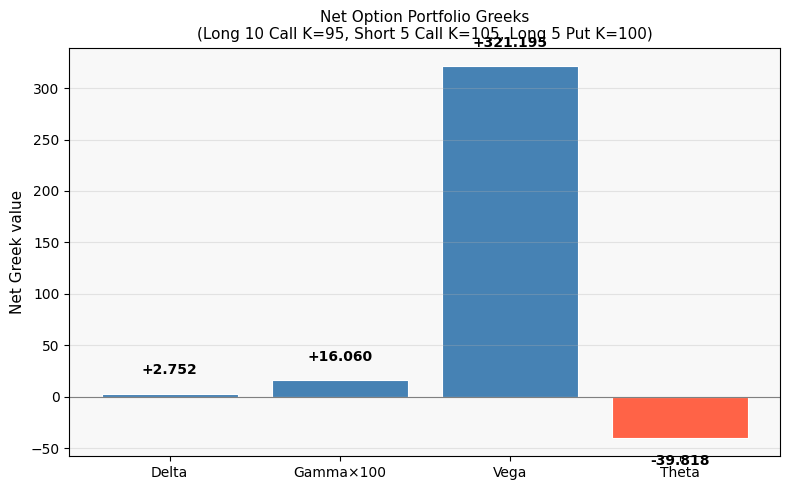

In [6]:
greek_names  = ['Delta', 'Gamma×100', 'Vega', 'Theta']
greek_values = [net_delta, net_gamma * 100, net_vega, net_theta]
colors = ['steelblue' if v >= 0 else 'tomato' for v in greek_values]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(greek_names, greek_values, color=colors, edgecolor='white', linewidth=0.8)

# Annotate bar tops
for bar, val in zip(bars, greek_values):
    offset = 0.05 * max(abs(v) for v in greek_values)
    va = 'bottom' if val >= 0 else 'top'
    y  = val + offset if val >= 0 else val - offset
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f'{val:+.3f}',
        ha='center', va=va, fontsize=10, fontweight='bold'
    )

ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('Net Greek value', fontsize=11)
ax.set_title(
    'Net Option Portfolio Greeks\n'
    '(Long 10 Call K=95, Short 5 Call K=105, Long 5 Put K=100)',
    fontsize=11
)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()

### 5b. Bond DV01 per position

DV01 (dollar value of 01) shows how much the portfolio value changes for a 1bp parallel shift in yields.  
Bond A contributes more DV01 despite its lower coupon because it has a longer maturity (higher duration).

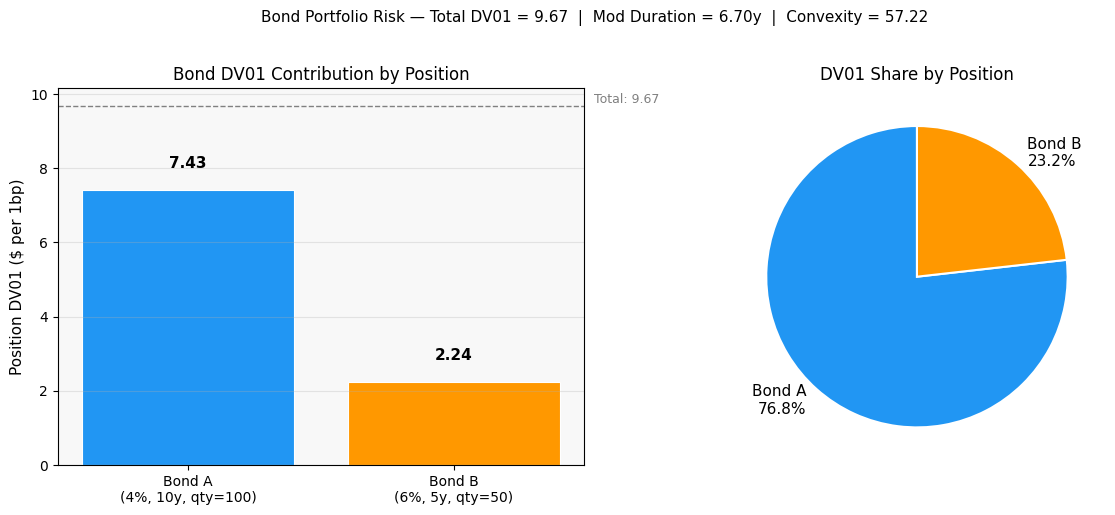

In [7]:
bond_labels  = ['Bond A\n(4%, 10y, qty=100)', 'Bond B\n(6%, 5y, qty=50)']
dv01_a = 100 * ana_a.dv01(SETTLE, YTM_A)
dv01_b = 50  * ana_b.dv01(SETTLE, YTM_B)
dv01_values = [dv01_a, dv01_b]
total_dv01  = dv01_a + dv01_b

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar chart: position DV01 ---
bar_colors = ['#2196F3', '#FF9800']
bars = ax1.bar(bond_labels, dv01_values, color=bar_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, dv01_values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.5,
        f'{val:.2f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax1.axhline(total_dv01, color='grey', linestyle='--', linewidth=1)
ax1.text(
    1.02, total_dv01,
    f'Total: {total_dv01:.2f}',
    transform=ax1.get_yaxis_transform(),
    va='bottom', fontsize=9, color='grey'
)
ax1.set_ylabel('Position DV01 ($ per 1bp)', fontsize=11)
ax1.set_title('Bond DV01 Contribution by Position', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('#f8f8f8')

# --- Pie chart: DV01 share ---
wedge_labels = [f'Bond A\n{dv01_a / total_dv01:.1%}', f'Bond B\n{dv01_b / total_dv01:.1%}']
ax2.pie(
    dv01_values,
    labels=wedge_labels,
    colors=bar_colors,
    autopct='',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=11),
)
ax2.set_title('DV01 Share by Position', fontsize=12)

plt.suptitle(
    f'Bond Portfolio Risk — Total DV01 = {total_dv01:.2f}  |  '
    f'Mod Duration = {risk.modified_duration:.2f}y  |  '
    f'Convexity = {risk.convexity:.2f}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()